<a href="https://colab.research.google.com/github/mehreen18/AI/blob/main/img_convulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch.nn as nn
import seaborn as sns
import numpy as np
import torchvision
from torch.utils.data import DataLoader

In [2]:
transform = transforms.ToTensor()

In [3]:
import torchvision
train_data = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.1MB/s]


In [4]:
test_data=torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

In [5]:
len(train_data)


60000

In [6]:
len(test_data)

10000

In [7]:
img, label=train_data[0]
img.shape


torch.Size([1, 28, 28])

In [8]:
label

9

In [9]:
train_loader = DataLoader(train_data, batch_size=512,shuffle=True)

In [10]:
test_loader=DataLoader(test_data, batch_size=512 , shuffle=False)

In [11]:
class_labels=["T_shirt/Top", "Trouser", "pullover", "Dress","coat","sandal", "shirt","sneakers", "bag","Ankel boot"]

Text(0.5, 1.0, '9')

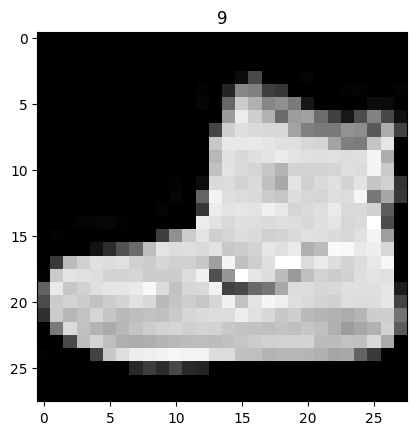

In [12]:
imag ,label= train_data[0]
plt.imshow(imag.squeeze(), cmap='gray')
plt.title(label)

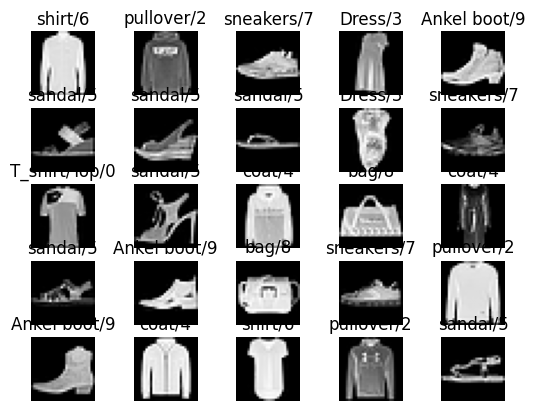

In [13]:
plt.Figure(figsize=(16,16))
j=1
for i in np.random.randint(0,1000,25):
  imag, label=train_data[i]
  plt.subplot(5,5, j); j+=1
  plt.imshow(imag.squeeze(), cmap='gray')
  plt.axis('off')
  plt.title('{}/{}'. format(class_labels[label] , label))


In [16]:
transform=transforms.ToTensor()
image,label =train_data[0]


In [17]:
image.min()


tensor(0.)

In [18]:
image.max()



tensor(1.)

In [19]:
image.shape

torch.Size([1, 28, 28])

In [24]:
nn.Conv2d(
    in_channels=1,
    out_channels=32,
    kernel_size=3,
    stride=1,
    padding=0
)

Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))

In [26]:
nn.MaxPool2d(kernel_size=2)

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

In [30]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=0
        )
        self.pool = nn.MaxPool2d(kernel_size=2)
        # After conv1 and pool, the dimensions will be 32x13x13 (from 1x28x28 -> 32x26x26 -> 32x13x13)
        self.fc1 = nn.Linear(32 * 13 * 13, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.conv1(x))
        x = x.view(x.size(0), -1)  # Flatten for fully connected layers
        x = self.fc1(x)
        x = self.fc2(x)
        return x

In [31]:
model=CNN()


In [33]:
criterion= nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters())

In [36]:
for epoch in range(10):
  model.train()
  running_Loss = 0.0 # Initialize as float for accumulation
  for images, Labels in train_loader:
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, Labels)
    loss.backward()
    optimizer.step()
    running_Loss += loss.item() # Accumulate loss per batch
  # Print average loss for the epoch after the inner loop
  print(f"epochs {epoch + 1} : loss={running_Loss / len(train_loader): .4f}")

epochs 1 : loss= 0.2645
epochs 2 : loss= 0.2545
epochs 3 : loss= 0.2459
epochs 4 : loss= 0.2399
epochs 5 : loss= 0.2333
epochs 6 : loss= 0.2276
epochs 7 : loss= 0.2260
epochs 8 : loss= 0.2175
epochs 9 : loss= 0.2093
epochs 10 : loss= 0.2087


In [39]:
model.eval()
image,  Label=test_data[0]
with torch.no_grad():
  output= model(image.unsqueeze(0))
  probs= torch.softmax(output,dim=1)
  predicted=torch.argmax(probs,dim=1)
predicted.item()
Label

9

In [38]:
correct, total= 0,0
model.eval()
with torch.no_grad():
  for images, Labels in test_loader:
    outputs = model(images)
    predicted =torch.argmax(outputs,dim= 1)
    correct += (predicted == Labels).sum().item()
    total += Labels.size(0)

accuracy =correct /total
print(f"test accuracy { accuracy: .4f}")


test accuracy  0.8921


              precision    recall  f1-score   support

 T_shirt/Top       0.81      0.87      0.84      1000
     Trouser       0.98      0.98      0.98      1000
    pullover       0.83      0.82      0.83      1000
       Dress       0.90      0.90      0.90      1000
        coat       0.87      0.79      0.83      1000
      sandal       0.97      0.97      0.97      1000
       shirt       0.70      0.72      0.71      1000
    sneakers       0.92      0.97      0.95      1000
         bag       0.97      0.97      0.97      1000
  Ankel boot       0.98      0.93      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



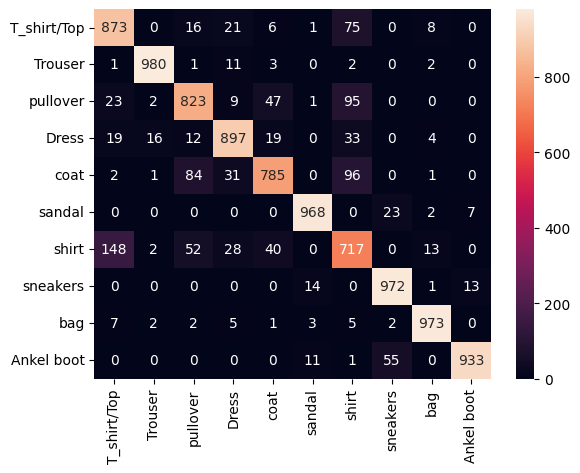

In [41]:
all_preds , all_Labels =[] ,[]
with torch.no_grad():
  for images, Labels in test_loader:
    preds= torch.argmax(model(images), dim=1)
    all_preds.extend(preds.numpy())
    all_Labels.extend(Labels.numpy())
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(all_Labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
print(classification_report(all_Labels, all_preds, target_names=class_labels))

In [44]:
torch.save(model.state_dict(), 'fashion_cnn_model.pth')
model_deploye=CNN()
model_deploye.load_state_dict(torch.load('fashion_cnn_model.pth'))
model_deploye.eval()
output =model_deploye(image.unsqueeze(0))